In [502]:
# neccessary imports
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [503]:
# dataset
df = pd.read_csv('iris.csv')

In [504]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [505]:
df = df.drop(columns='Id', axis=1)

In [506]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [507]:
label_encoder = LabelEncoder()

In [508]:
# encoding the output column
df['Species'] = label_encoder.fit_transform(df['Species'])

In [509]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [510]:
# making this problem into a binary classification problem, by removing 2's and just keeping 1's and 0's
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]

In [511]:
df.shape

(100, 3)

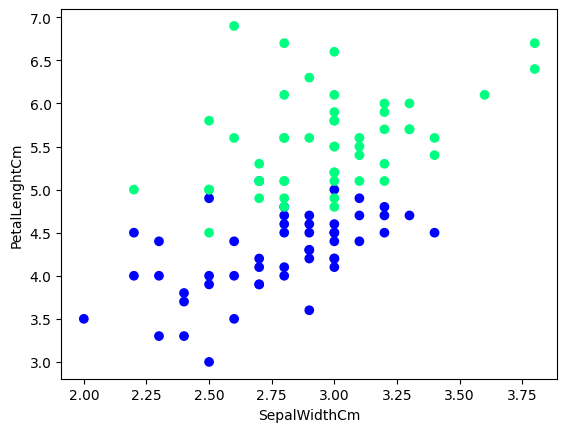

In [512]:
plt.xlabel('SepalWidthCm')
plt.ylabel('PetalLenghtCm')
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'], c=df['Species'], cmap='winter')
plt.show()

In [513]:
# shuffling our dataset 
df = df.sample(100) 

In [514]:
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [515]:
# Test data
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

## Case 1 -Bagging
- `Row sampling with replacement`

In [516]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True) # allowing duplicate rows

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [517]:
df_bag

,SepalWidthCm,PetalLengthCm,Species
122,2.8,6.7,2
57,2.4,3.3,1
141,3.1,5.1,2
120,3.2,5.7,2
119,2.2,5.0,2
58,2.9,4.6,1
119,2.2,5.0,2
120,3.2,5.7,2


In [518]:
dt_bag1 = DecisionTreeClassifier()

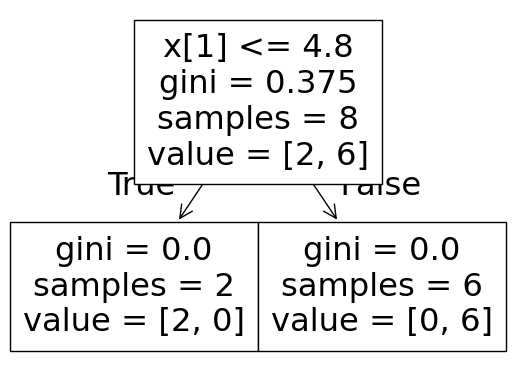

1.0


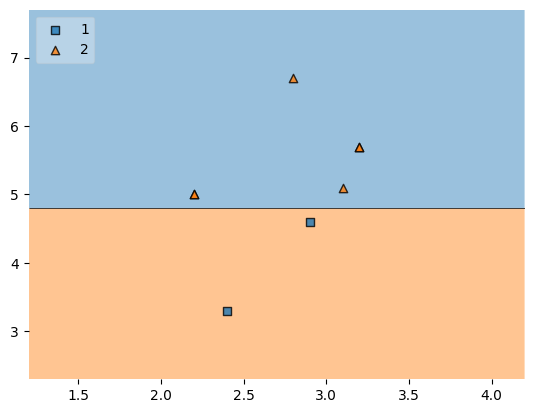

In [519]:
evaluate(dt_bag1, X, y)

In [520]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
120,3.2,5.7,2
58,2.9,4.6,1
122,2.8,6.7,2
120,3.2,5.7,2
57,2.4,3.3,1
98,2.5,3.0,1
119,2.2,5.0,2


In [521]:
dt_bag2 = DecisionTreeClassifier()

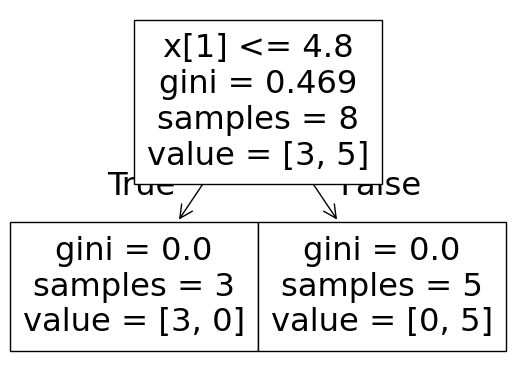

1.0


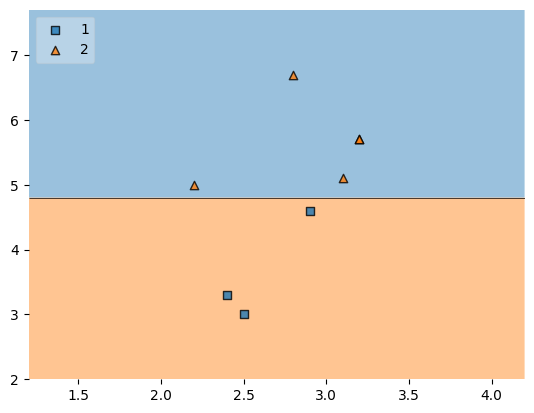

In [522]:
evaluate(dt_bag2, X, y)

In [523]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
120,3.2,5.7,2
50,3.2,4.7,1
57,2.4,3.3,1
119,2.2,5.0,2
98,2.5,3.0,1
50,3.2,4.7,1
120,3.2,5.7,2
102,3.0,5.9,2


In [524]:
dt_bag3 = DecisionTreeClassifier()

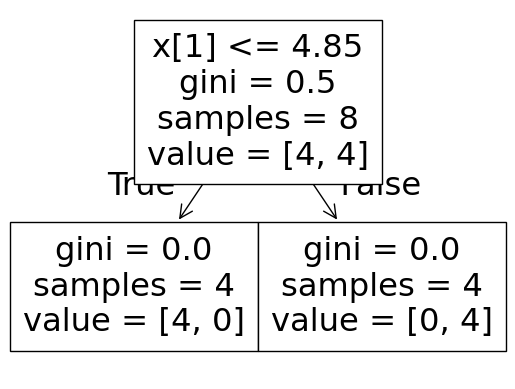

0.8


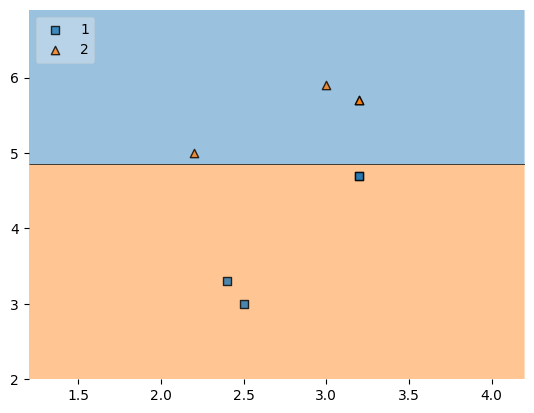

In [525]:
evaluate(dt_bag3, X, y)

In [526]:
df_test

,SepalWidthCm,PetalLengthCm,Species
130,2.8,6.1,2
114,2.8,5.1,2
135,3.0,6.1,2
128,2.8,5.6,2
56,3.3,4.7,1


In [527]:
print("Predictor 1: ", dt_bag1.predict(np.array([3.0, 4.7]).reshape(1,2)))
print("Predictor 2: ", dt_bag2.predict(np.array([3.0, 4.7]).reshape(1,2)))
print("Predictor 3: ", dt_bag3.predict(np.array([3.0, 4.7]).reshape(1,2)))

Predictor 1:  [1]
Predictor 2:  [1]
Predictor 3:  [1]


In [528]:
def evaluate(clf, X, y):
    clf.fit(X, y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

## Pasting
- `It is same as Bagging but, without replacement`

In [529]:
df_train

,SepalWidthCm,PetalLengthCm,Species
122,2.8,6.7,2
58,2.9,4.6,1
62,2.2,4.0,1
98,2.5,3.0,1
120,3.2,5.7,2
102,3.0,5.9,2
50,3.2,4.7,1
57,2.4,3.3,1
141,3.1,5.1,2
119,2.2,5.0,2


In [530]:
# Row sampling without replacement
df_train.sample(8, replace=False)

,SepalWidthCm,PetalLengthCm,Species
98,2.5,3.0,1
58,2.9,4.6,1
62,2.2,4.0,1
120,3.2,5.7,2
122,2.8,6.7,2
50,3.2,4.7,1
119,2.2,5.0,2
141,3.1,5.1,2


## Random Subspaces:
- `Column sampling with/without replacement`

In [531]:
df1 = pd.read_csv('iris.csv')

In [532]:
df1 = df1.sample(10)

In [533]:
df1_input_cols = df1.iloc[:,0:-1]

In [534]:
# random subspaces with replacement- Allowing duplicate cols.
df1_input_cols.sample(2, replace=True, axis=1)

,Id,SepalWidthCm
55,56,2.8
4,5,3.6
36,37,3.5
141,142,3.1
68,69,2.2
149,150,3.0
59,60,2.7
138,139,3.0
43,44,3.5
95,96,3.0


In [535]:
# random subspaces without replacement- Not allowing duplicate cols.
df1_input_cols.sample(2, replace=False, axis=1)

,SepalWidthCm,PetalLengthCm
55,2.8,4.5
4,3.6,1.4
36,3.5,1.3
141,3.1,5.1
68,2.2,4.5
149,3.0,5.1
59,2.7,3.9
138,3.0,4.8
43,3.5,1.6
95,3.0,4.2


## Random Patches:
- `Row sampling and Columns sampling Simultaneously`

In [536]:
df_for_random_patches = df1.iloc[:,0:-1]

In [537]:
df_for_random_patches.sample(100, replace=True).sample(3, replace=True, axis=1)

,SepalLengthCm,PetalLengthCm,SepalLengthCm
43,5.0,1.6,5.0
68,6.2,4.5,6.2
68,6.2,4.5,6.2
141,6.9,5.1,6.9
95,5.7,4.2,5.7
...,...,...,...
4,5.0,1.4,5.0
95,5.7,4.2,5.7
36,5.5,1.3,5.5
138,6.0,4.8,6.0
